# 02 — CBIS-DDSM Dataset Exploration
**Goal:** Understand the classification dataset at every step

Steps:
1. Raw CSV analysis
2. Raw JPEG crops inspection
3. Interim crops (after conversion)
4. Processed crops (after CLAHE)
5. Classification patches (224×224 organized)

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH  = Path('../data/interim/cbis_ddsm/cbis_ddsm_cases.csv')
INT_CROPS = Path('../data/interim/cbis_ddsm/Crops')
PROC_CROPS= Path('../data/processed/cbis_ddsm/Crops')
CLS_DIR   = Path('../data/patches/classification')
RAW_CSV   = Path('../data/raw/cbis_ddsm/csv')

print('Setup complete')

Setup complete


## 1. Raw CSV Analysis

Raw CSV counts:
  calc_train: 1546
  calc_test : 326
  mass_train: 1318
  mass_test : 378
  Total     : 3568

Pathology distribution:
pathology
MALIGNANT                  1457
BENIGN                     1429
BENIGN_WITHOUT_CALLBACK     682
Name: count, dtype: int64


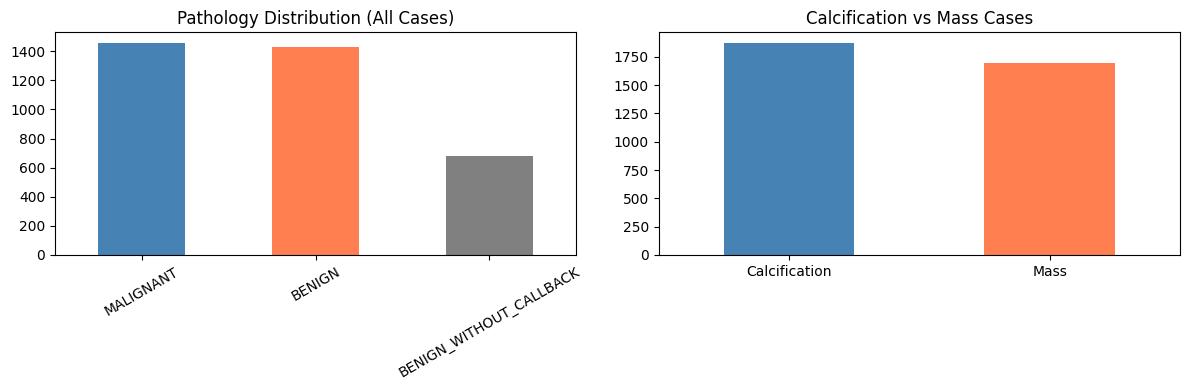

In [2]:
# Load original CSVs
calc_train = pd.read_csv(str(RAW_CSV / 'calc_case_description_train_set.csv'))
calc_test  = pd.read_csv(str(RAW_CSV / 'calc_case_description_test_set.csv'))
mass_train = pd.read_csv(str(RAW_CSV / 'mass_case_description_train_set.csv'))
mass_test  = pd.read_csv(str(RAW_CSV / 'mass_case_description_test_set.csv'))

print('Raw CSV counts:')
print(f'  calc_train: {len(calc_train)}')
print(f'  calc_test : {len(calc_test)}')
print(f'  mass_train: {len(mass_train)}')
print(f'  mass_test : {len(mass_test)}')
print(f'  Total     : {len(calc_train)+len(calc_test)+len(mass_train)+len(mass_test)}')

# Pathology distribution
combined = pd.concat([calc_train, calc_test, mass_train, mass_test])
print(f'\nPathology distribution:')
print(combined.pathology.value_counts())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
combined.pathology.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral','gray'])
axes[0].set_title('Pathology Distribution (All Cases)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Calc vs Mass
type_counts = pd.Series({'Calcification': len(calc_train)+len(calc_test),
                          'Mass': len(mass_train)+len(mass_test)})
type_counts.plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Calcification vs Mass Cases')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 2. Our Unified CSV

Unified CSV: 3567 cases

Label distribution:
label
0    2110
1    1457
Name: count, dtype: int64

Case type:
case_type
calc    1871
mass    1696
Name: count, dtype: int64

Original split:
orig_split
train    2863
test      704
Name: count, dtype: int64


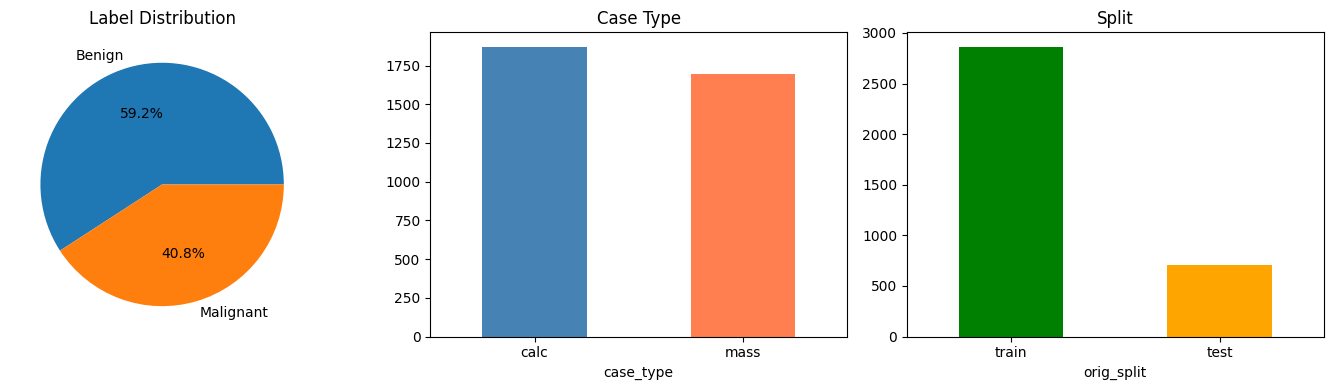

In [3]:
df = pd.read_csv(str(CSV_PATH))
print(f'Unified CSV: {len(df)} cases')
print(f'\nLabel distribution:')
print(df.label.value_counts())
print(f'\nCase type:')
print(df.case_type.value_counts())
print(f'\nOriginal split:')
print(df.orig_split.value_counts())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df.label.map({0:'Benign',1:'Malignant'}).value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Label Distribution')
df.case_type.value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Case Type'); axes[1].tick_params(axis='x', rotation=0)
df.orig_split.value_counts().plot(kind='bar', ax=axes[2], color=['green','orange'])
axes[2].set_title('Split'); axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3. Raw JPEG Crops vs Processed Crops (CLAHE)

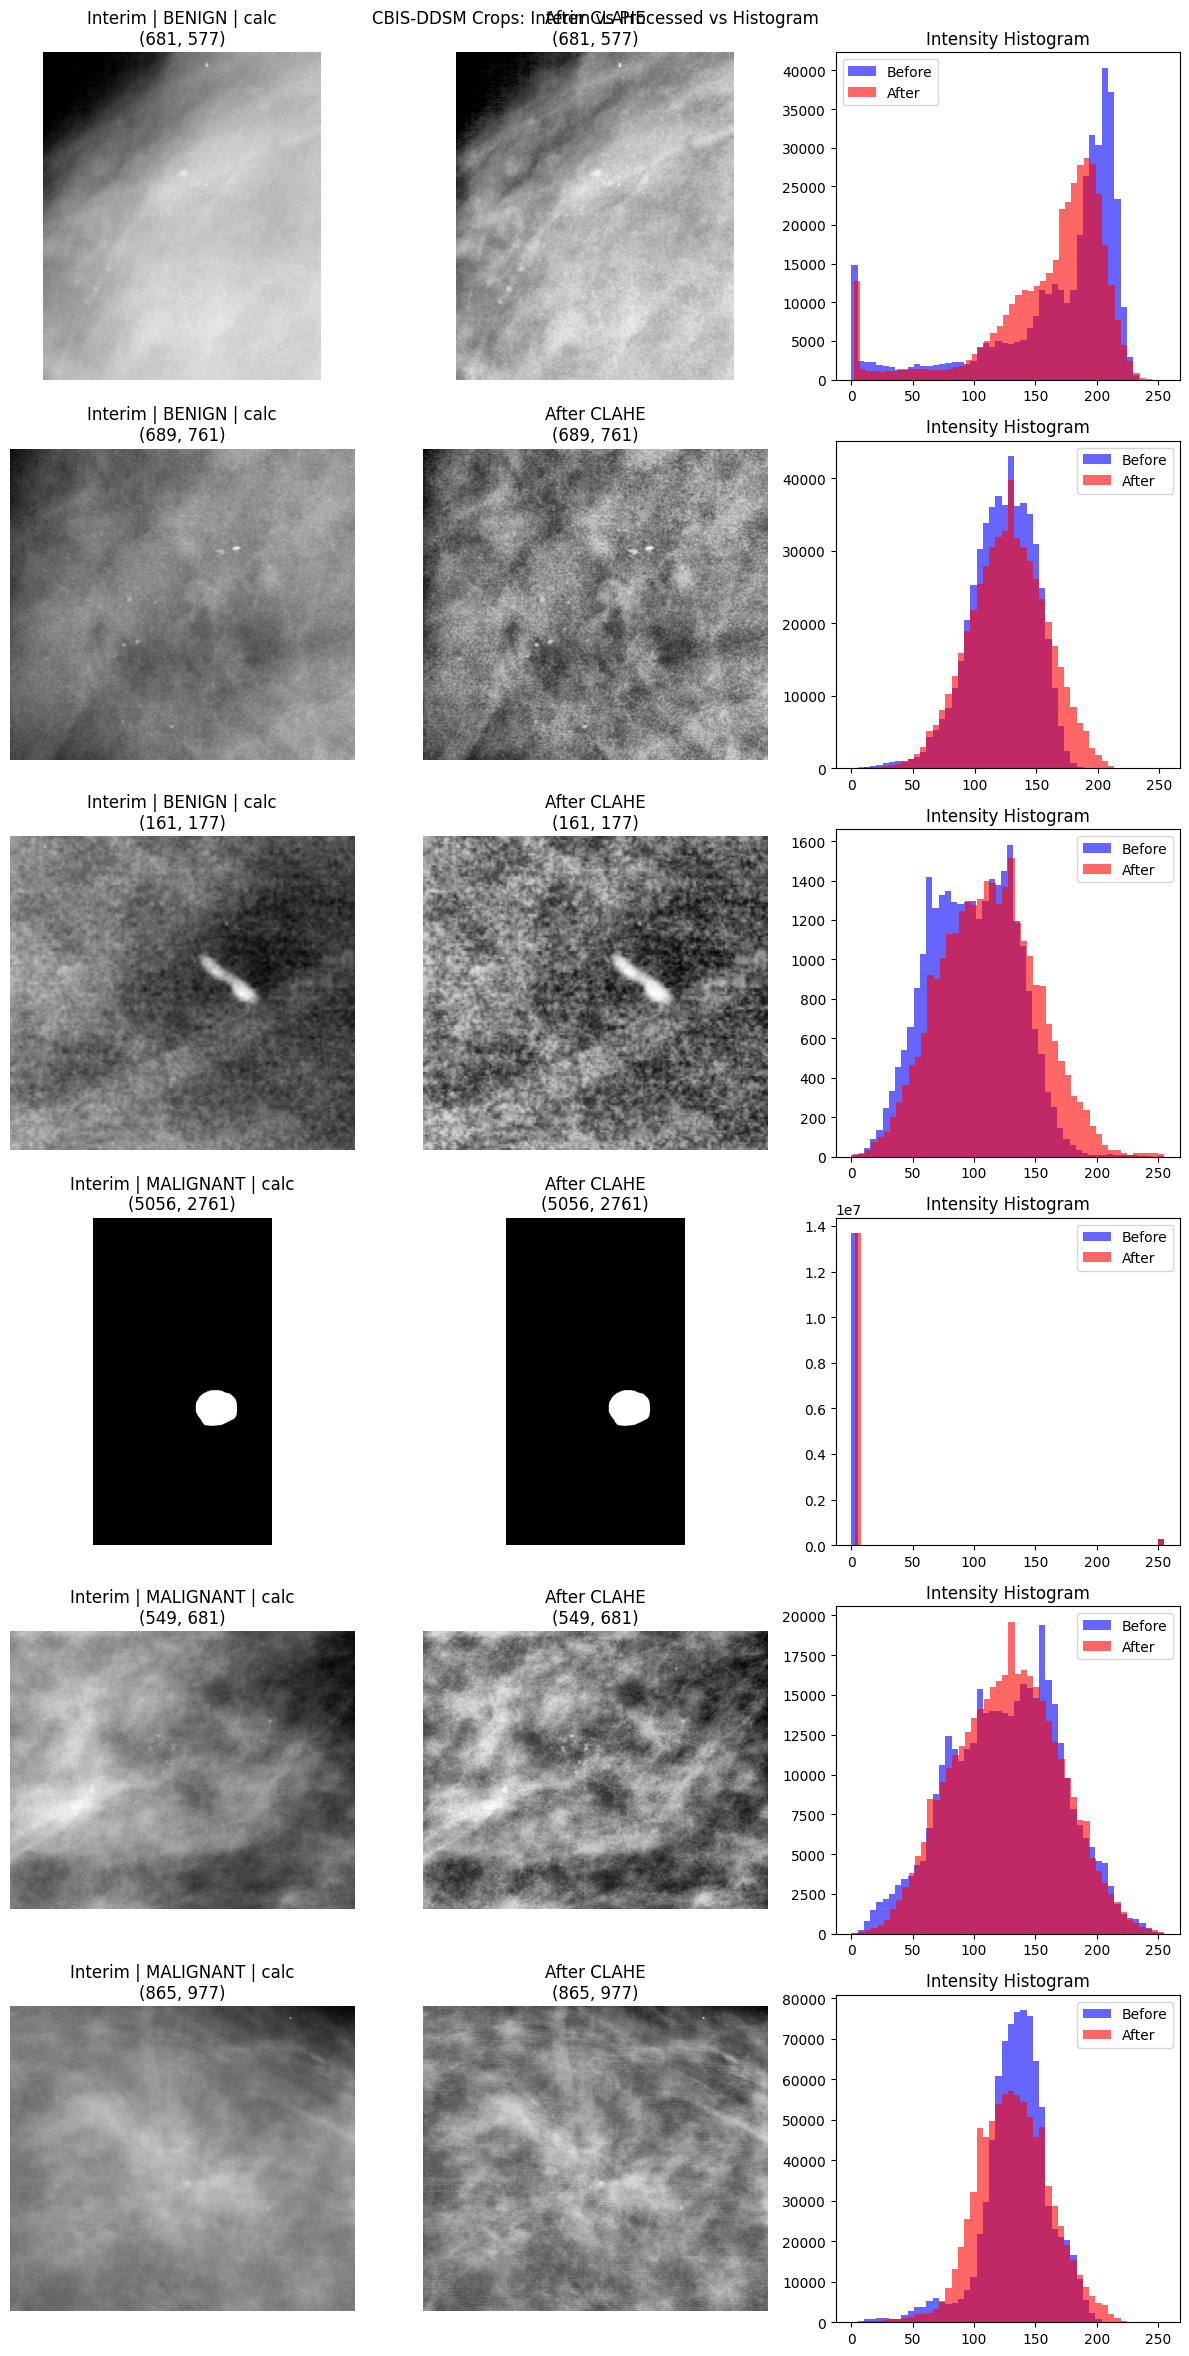

In [4]:
df_valid = df[df.crop_png.notna()].copy()
benign_cases    = df_valid[df_valid.label == 0].head(3)
malignant_cases = df_valid[df_valid.label == 1].head(3)
sample = pd.concat([benign_cases, malignant_cases])

fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4*len(sample)))
fig.suptitle('CBIS-DDSM Crops: Interim vs Processed vs Histogram', fontsize=12)

for row, (_, r) in enumerate(sample.iterrows()):
    img_int  = cv2.imread(str(INT_CROPS  / r.crop_png), cv2.IMREAD_GRAYSCALE)
    img_proc = cv2.imread(str(PROC_CROPS / r.crop_png), cv2.IMREAD_GRAYSCALE)
    label    = 'MALIGNANT' if r.label == 1 else 'BENIGN'

    if img_int is None or img_proc is None:
        continue

    axes[row,0].imshow(img_int,  cmap='gray')
    axes[row,0].set_title(f'Interim | {label} | {r.case_type}\n{img_int.shape}')
    axes[row,0].axis('off')

    axes[row,1].imshow(img_proc, cmap='gray')
    axes[row,1].set_title(f'After CLAHE\n{img_proc.shape}')
    axes[row,1].axis('off')

    axes[row,2].hist(img_int.flatten(),  bins=50, alpha=0.6, label='Before', color='blue')
    axes[row,2].hist(img_proc.flatten(), bins=50, alpha=0.6, label='After',  color='red')
    axes[row,2].legend(); axes[row,2].set_title('Intensity Histogram')

plt.tight_layout()
plt.show()

## 4. Final Classification Patches (224×224)

Classification patch counts:
  train/benign    : 1340
  train/malignant : 938
  val  /benign    : 342
  val  /malignant : 243
  test /benign    : 428
  test /malignant : 276
  Total: 3567


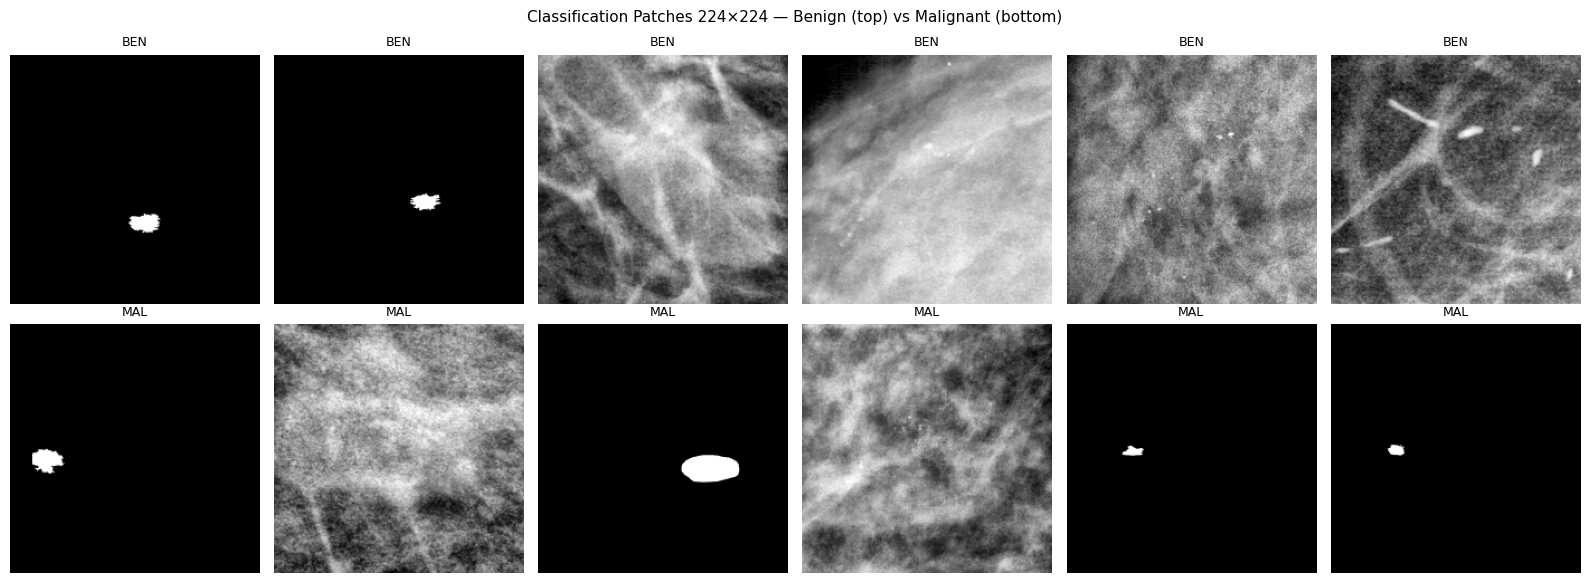


All patches are 224×224: True


In [8]:
# Count patches per split
print('Classification patch counts:')
total = 0
for split in ['train', 'val', 'test']:
    for label in ['benign', 'malignant']:
        d = CLS_DIR / split / label
        n = len(list(d.glob('*.png'))) if d.exists() else 0
        print(f'  {split:5s}/{label:10s}: {n}')
        total += n
print(f'  Total: {total}')

# Show sample patches
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Classification Patches 224×224 — Benign (top) vs Malignant (bottom)', fontsize=11)

for label in ['benign', 'malignant']:
    row = 1 if label == 'malignant' else 0   # ✅ FIX

    patches = sorted((CLS_DIR/'train'/label).glob('*.png'))[:6]
    for i, p in enumerate(patches):
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)

        axes[row, i].imshow(img, cmap='gray')
        axes[row, i].set_title(label.upper()[:3], fontsize=9)
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()

# Image size verification
sample_patches = list((CLS_DIR/'train'/'benign').glob('*.png'))[:10]
sizes = [cv2.imread(str(p), cv2.IMREAD_GRAYSCALE).shape for p in sample_patches]
print(f'\nAll patches are 224×224: {all(s == (224,224) for s in sizes)}')